# Murphy and Freddy: observations versus SEACOFS climatology

**Question:** are the two observed cyclones' tilt directions and tilt rates typical of nearby model cyclones with comparable peak Rossby number and profiles reaching at least 600 m?

Source: [Roughan et al. (2017), JGR Oceans, doi:10.1002/2016JC012241](https://doi.org/10.1002/2016JC012241), Table 4 and Figures 10–11, sections 4.1, 5.2–5.3. This is a conditional climatological comparison, not an event reconstruction or a validation from two independent populations. Run on Katana with the existing processed/confirmed-profile/tilt tables; no multi-year cache build is needed.

## Measurements and necessary corrections

| Quantity | Murphy | Freddy (first visit) |
|---|---:|---:|
| Representative ADCP centre (Table 4) | 28.6168°S, 154.8351°E | 32.5763°S, 153.2057°E |
| Radius used for geographic search | 80 km | 17.5 km |
| Published tilt rate | 3.3 km/100 m | 1.5 km/100 m |
| Reported deep-to-shallow compass bearing | 248.8° (21.2° S of W) | 250.3° (19.7° S of W) |
| Published displacement over approximately 700 m | 23 km | 10 km |
| Approximate peak paper Ro, Figure 11 mean curve | 0.37 | 0.65 |

These Ro peaks are **visual estimates**, not digitised observations or upper confidence limits. They replace the original 0.35/0.60 estimates; adjust them below if better digitisation becomes available. The abstract's ranges differ from Figure 11 and section 5.3; we use the latter. Radii are reported size estimates, not necessarily the model's fitted Gaussian radius. Table 4 lists several moving centres: the first estimate for each first visit is the explicit default, not a claim that all measurements occurred at that point.

**Direction:** Figure 10 shows centres farther east/north at greater depth; its quoted SW direction is deep-to-shallow, consistent with saved `TiltDir`. A surface-to-depth arrow would instead point NE. Do not reverse the observations automatically.

**Ro:** the paper calls its parameter Ω vorticity, but defines `Vθ = Ω r` and `T = 2π/|Ω|`. For that circular solid-body model, relative vorticity is `ζ = 2Ω`. Therefore the inferred targets for the model's `w/f = ζ/f` are **0.74 and 1.30**. The original `Ro × f` calculations estimate Ω, not ζ. This conversion follows the stated velocity relation; it is an interpretation of the paper's convention, not a reanalysis of its ADCP data. The model explicitly computes `w = Omega*(q11+q22)`; do not identify its noncircular `Omega` directly with the paper's Ω.

**Depth and estimator:** section 5.2 quotes displacements over 700 m; Figure 10 extends to roughly that depth. Keep the requested ≥600 m selection. For a comparable upper-column rate, fit daily model centres at actual levels from 50 m to the first valid level at/just below 600 m (at most 100 m deeper), reporting the actual endpoints. No interpolation or extrapolated profile support. The paper uses inverse-error-variance weighted fits; the model comparison uses ordinary least squares because equivalent observation errors are unavailable. Daily linear tilt differs from the saved temporally smoothed coherent delta tilt, so the latter is shown separately.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Works from the notebook directory or anywhere inside UNSW-PhD.
root = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'seacofs_eddy_tilt_analysis').is_dir()), None)
if root is None:
    raise RuntimeError('Run from inside the UNSW-PhD checkout.')
analysis = root / 'seacofs_eddy_tilt_analysis'
sys.path.insert(0, str(analysis))
sys.path.insert(0, str(analysis / 'real_obs'))
import seacofs_tilt_tools as tilt
import obs_clim_tools as obs_tools

PATHS = tilt.Paths()                 # Existing Katana defaults; override here if needed.
RADIUS_FACTOR = 1.0                  # Radius of OBSERVED eddy, not model radius.
RO_FRACTION = 2.0 #0.25                   # ±25% of observed converted peak Ro.
TARGET_DEPTH_M = 600.
DEPTH_TOLERANCE_M = 100.
FIT_MIN_DEPTH_M = 50.                # Avoid the surface layer noted in the paper.
INCLUDE_PV = True                    # Small centre-point environmental comparison.
SAVE_RESULTS = False
OUTPUT = analysis / 'real_obs' / 'outputs'

obs = obs_tools.observations()
# Edit paper_Ro_peak above in obs_tools.observations(), or explicitly update
# both Ro_zeta_target and zeta_s-1 here when exploring an alternative reading.
display(obs)


,name,lat,lon,radius_km,paper_Ro_peak,rate_km_per_100m,bearing_deg,published_distance_km,date,f_s-1,paper_Omega_s-1,zeta_s-1,Ro_zeta_target,equivalent_600m_km
0,Murphy,-28.6168,154.8351,80.0,0.37,3.3,248.8,23.0,2015-06-05 03:30,-0.000070,-0.000026,-0.000052,0.74,19.8
1,Freddy,-32.5763,153.2057,17.5,0.65,1.5,250.3,10.0,2015-06-09 00:15,-0.000079,-0.000051,-0.000102,1.30,9.0


## Load and match

All seasons/years, CE only, within `1.5 × observed radius`, and peak signed `w/f` over **0–600 m** within ±25% of the converted observed peak. No tilt magnitude, direction, PV regime or shelf-depth filter is used to select matches. The last fit level can be slightly deeper than 600 m, but it never enters the 0–600 m Ro search. At least three fit levels and a shallow fit level within 100 m of the requested minimum are required. Both `(Eddy, Day)` keys are retained throughout.

The 1.5-radius windows differ substantially: 120 km for Murphy and 26.25 km for Freddy. This is a user-selected location rule, not radius matching. Counts are **eddy-days** and distinct **eddy tracks**; distributions and quantiles weight days equally. They are descriptive population spread, not confidence intervals or independent-sample tests.


In [2]:
for path in [PATHS.eddies, PATHS.tilt, PATHS.vert, PATHS.grid, PATHS.z_r]:
    if not Path(path).exists():
        raise FileNotFoundError(f'Missing production input: {path}. Run on Katana or update PATHS.')
# Check raw join keys before using the shared loader.
obs_tools.unique(tilt.read_table(PATHS.eddies), ['Eddy', 'Day'])
obs_tools.unique(tilt.read_table(PATHS.tilt), ['Eddy', 'Day'])
surface, saved_tilt = tilt.load_tilt_tables(PATHS)
vertical = tilt.load_vert(PATHS)
grid = tilt.load_grid(PATHS.grid, PATHS.z_r)
obs_tools.unique(vertical, ['Eddy', 'Day', 'Depth'])

# Restrict expensive profile fitting to local CE candidates, without using tilt outcomes.
local = np.zeros(len(surface), dtype=bool)
for o in obs.itertuples(index=False):
    local |= tilt.distance_km(surface.lat, surface.lon, o.lat, o.lon) <= RADIUS_FACTOR*o.radius_km
candidate = surface.loc[local & surface.Cyc.eq('CE')].copy()
profiles = vertical.merge(candidate[['Eddy', 'Day']], on=['Eddy', 'Day'], validate='many_to_one')
metrics = obs_tools.profile_metrics(profiles, target_depth=TARGET_DEPTH_M,
    depth_tolerance=DEPTH_TOLERANCE_M, fit_min_depth=FIT_MIN_DEPTH_M,
    rotation_rad=grid.angle)
groups, audit = obs_tools.match(surface, metrics, obs, tilt.distance_km,
    radius_factor=RADIUS_FACTOR, ro_fraction=RO_FRACTION)
display(audit)
display(metrics.profile_status.value_counts().rename('candidate_days'))
print(f'Raw-centre rotation: {np.degrees(grid.angle):.3f} degrees; saved TiltDir is already geographic.')
for name, d in groups.items():
    print(name, 'actual fit depths / fit quality / Ro:')
    display(d[['fit_top_m', 'fit_bottom_m', 'fit_n', 'fit_r2', 'w_peak_depth_m', 'Ro_peak']].describe())


,observation,stage,days,eddies
0,Murphy,CE,62474,1536
1,Murphy,within search circle,731,71
2,Murphy,usable >=600m profile,540,61
3,Murphy,peak Ro within tolerance,540,61
4,Freddy,CE,62474,1536
5,Freddy,within search circle,46,19
6,Freddy,usable >=600m profile,44,18
7,Freddy,peak Ro within tolerance,44,18


profile_status
usable                              584
no endpoint at/just below target    169
Name: candidate_days, dtype: int64

Raw-centre rotation: -20.000 degrees; saved TiltDir is already geographic.
Murphy actual fit depths / fit quality / Ro:


,fit_top_m,fit_bottom_m,fit_n,fit_r2,w_peak_depth_m,Ro_peak
count,540.000000,5.400000e+02,540.0,540.000000,540.000000,540.000000
mean,60.170639,6.608064e+02,13.0,0.777482,15.085461,0.402992
std,0.000000,1.137922e-13,0.0,0.236703,27.879127,0.179692
min,60.170639,6.608064e+02,13.0,0.005095,0.000000,0.110302
25%,60.170639,6.608064e+02,13.0,0.683398,0.000000,0.288667
50%,60.170639,6.608064e+02,13.0,0.876405,0.000000,0.369676
75%,60.170639,6.608064e+02,13.0,0.953653,16.383097,0.499390
max,60.170639,6.608064e+02,13.0,0.995933,181.264793,1.313345


Freddy actual fit depths / fit quality / Ro:


,fit_top_m,fit_bottom_m,fit_n,fit_r2,w_peak_depth_m,Ro_peak
count,4.400000e+01,4.400000e+01,44.0,44.000000,44.000000,44.000000
mean,6.017064e+01,6.608064e+02,13.0,0.705128,23.911412,0.490768
std,2.156272e-14,1.150012e-13,0.0,0.246355,37.152134,0.259299
min,6.017064e+01,6.608064e+02,13.0,0.144295,0.000000,0.165080
25%,6.017064e+01,6.608064e+02,13.0,0.612202,0.000000,0.331687
50%,6.017064e+01,6.608064e+02,13.0,0.759758,5.879627,0.395124
75%,6.017064e+01,6.608064e+02,13.0,0.904797,32.596267,0.687113
max,6.017064e+01,6.608064e+02,13.0,0.974501,126.288127,1.267356


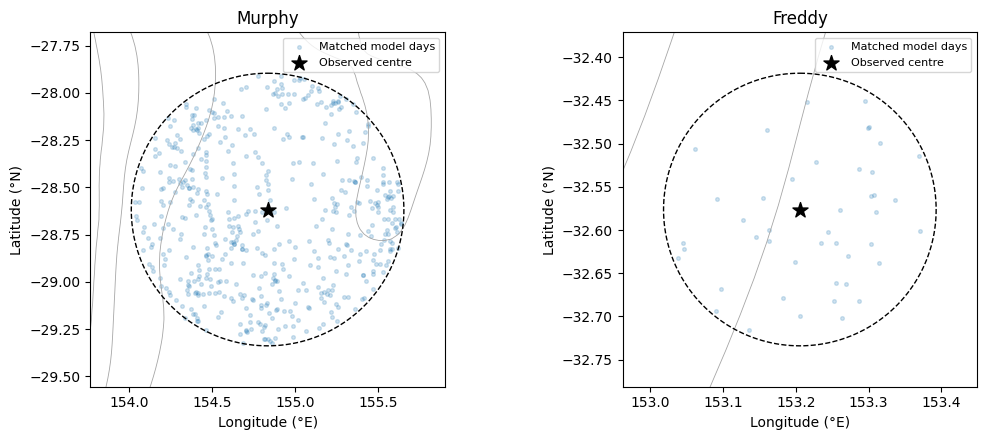

In [3]:
# Location check: selected centres, observed centres, search circles and shelf isobaths.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, o in zip(axes, obs.itertuples(index=False)):
    d = groups[o.name]
    ax.contour(grid.lon_rho, grid.lat_rho, np.where(grid.mask_rho, grid.h, np.nan),
               levels=[200, 1000, 3000], colors='0.65', linewidths=.6)
    ax.scatter(d.lon, d.lat, s=7, alpha=.2, label='Matched model days')
    ax.scatter(o.lon, o.lat, marker='*', s=130, color='black', label='Observed centre')
    a = np.linspace(0, 2*np.pi, 181)
    # Spherical destination points for the same search radius (Earth radius matches helper).
    delta = RADIUS_FACTOR*o.radius_km/6357.
    lat0, lon0 = np.deg2rad([o.lat, o.lon])
    lat = np.arcsin(np.sin(lat0)*np.cos(delta)+np.cos(lat0)*np.sin(delta)*np.cos(a))
    lon = lon0 + np.arctan2(np.sin(a)*np.sin(delta)*np.cos(lat0),
                           np.cos(delta)-np.sin(lat0)*np.sin(lat))
    ax.plot(np.rad2deg(lon), np.rad2deg(lat), 'k--', lw=1)
    padlat = np.rad2deg(delta)*1.3
    padlon = padlat/np.cos(lat0)
    ax.set(xlim=(o.lon-padlon,o.lon+padlon), ylim=(o.lat-padlat,o.lat+padlat),
           xlabel='Longitude (°E)', ylabel='Latitude (°N)', title=o.name)
    ax.set_aspect(1/np.cos(lat0))
    ax.legend(fontsize=8)
fig.tight_layout()


## Tilt comparison

The direction panel uses circular differences: zero means agreement; ±180° means opposite. Direction is undefined for zero fitted tilt. The table reports day-weighted medians/IQRs and the observation's empirical percentile, with no significance test. `equivalent_600m_km = rate × 6` is **linear-fit implied displacement over 600 m**, not a separately observed endpoint displacement. It puts both rates on one depth scale (19.8 km and 9.0 km for the observations).

`TiltDis` is included only as whole-column context: its observed references are the paper's rounded ~700 m totals, while model delta tilt has variable depth support and temporal smoothing. **Do not treat its percentile as a matched-depth validation**, and do not divide it by 600 m.


,observation,metric,observed,days,eddies,model_q25,model_median,model_q75,observed_percentile
0,Murphy,rate_km_per_100m,3.3,540,61,1.527,2.527,4.177,65.370
1,Murphy,equivalent_600m_km,19.8,540,61,9.161,15.159,25.061,65.370
2,Murphy,TiltDis,23.0,495,56,11.108,18.971,30.899,58.990
3,Freddy,rate_km_per_100m,1.5,44,18,0.589,1.081,1.836,61.364
4,Freddy,equivalent_600m_km,9.0,44,18,3.537,6.485,11.018,61.364
5,Freddy,TiltDis,10.0,39,17,5.357,7.430,11.566,61.538


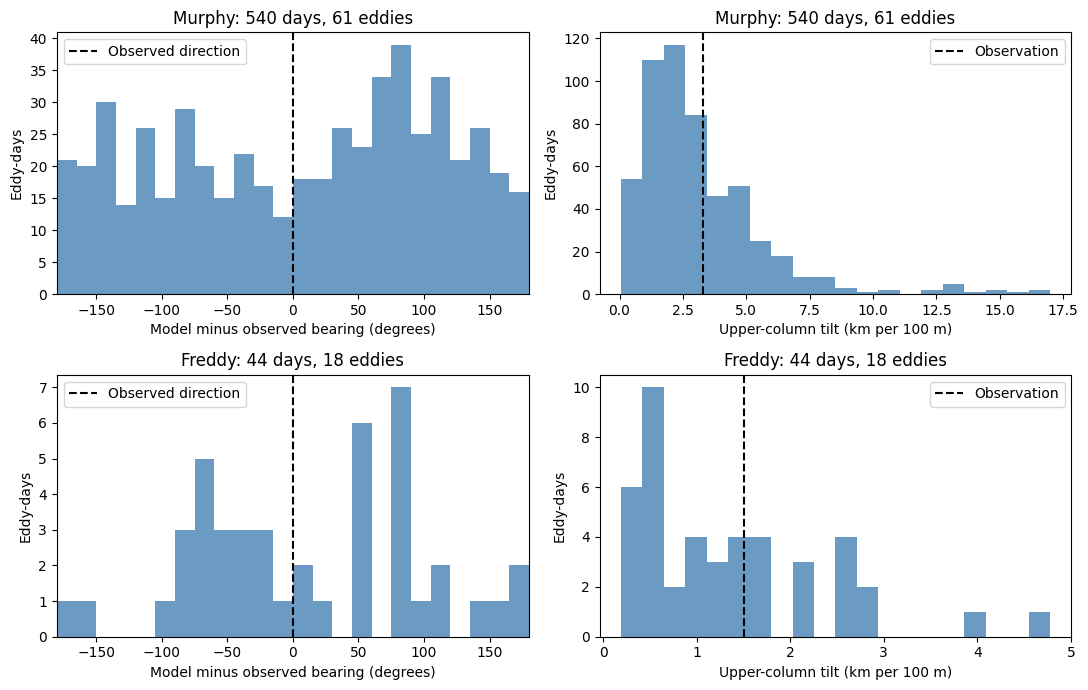

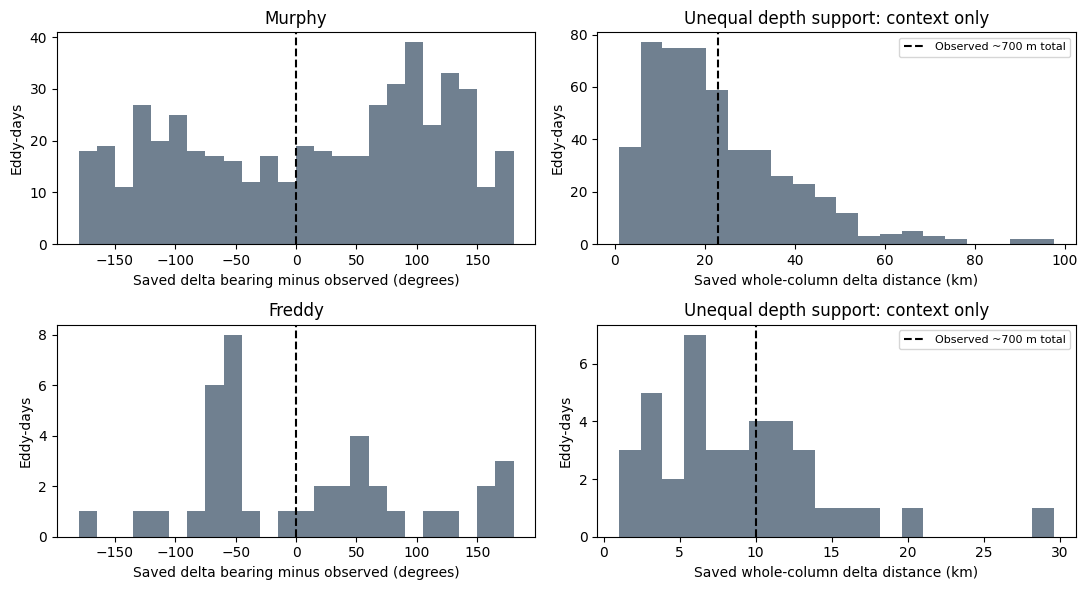

In [4]:
comparison = obs_tools.summary(groups, obs)
display(comparison.round(3))
comparison_figure = obs_tools.plot_comparison(groups, obs)
plt.show()

# The original climatological product, kept separate from the daily fitted comparison.
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, o in zip(axes, obs.itertuples(index=False)):
    d = groups[o.name]
    valid_dir = d.loc[d.TiltDis.gt(0) & np.isfinite(d.TiltDir)]
    ax[0].hist(obs_tools.angle_difference(valid_dir.TiltDir, o.bearing_deg),
               bins=np.linspace(-180,180,25), color='slategray')
    ax[0].axvline(0, color='black', linestyle='--')
    ax[0].set(xlabel='Saved delta bearing minus observed (degrees)', ylabel='Eddy-days', title=o.name)
    ax[1].hist(d.TiltDis.dropna(), bins=20, color='slategray')
    ax[1].axvline(o.published_distance_km, color='black', linestyle='--', label='Observed ~700 m total')
    ax[1].set(xlabel='Saved whole-column delta distance (km)', ylabel='Eddy-days', title='Unequal depth support: context only')
    ax[1].legend(fontsize=8)
fig.tight_layout()


55.0
14.0


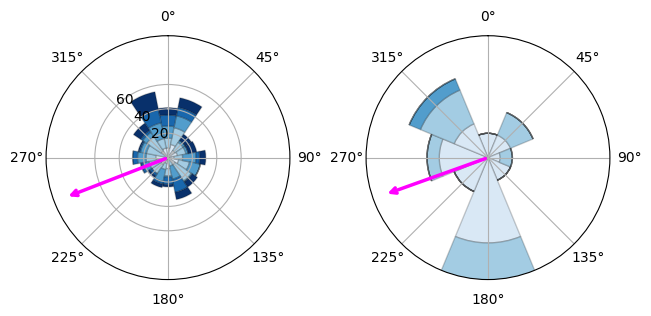

In [5]:
fig, axs = plt.subplots(1,2, subplot_kw={'projection':'polar'}, constrained_layout=True)
for ax, o in zip(axs, obs.itertuples(index=False)):
    d = groups[o.name]
    valid_dir = d.loc[d.TiltDis.gt(0) & np.isfinite(d.TiltDir)]
    ax = tilt.plot_windrose(ax, valid_dir, step=20, rlim=100 if o.name=='Murphy' else 10)
    
    th = np.deg2rad(o.bearing_deg)
    th = np.arctan2(np.mean(np.sin(th)), np.mean(np.cos(th)))
    ax.annotate('', xy=(th,.9*ax.get_ylim()[1]), xytext=(th,0),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='magenta'))

## Optional environmental PV context

This deliberately simple diagnostic samples **model-grid** bathymetry and gradients at each centre, for both observations and matched model days. It uses `g_plan = (0, β/h)` and `g_topo = -(f+ζ)∇h/h²`, with the same peak 0–600 m vorticity convention. The observational rows combine inferred observed ζ with model-grid environmental fields; they are **not measured PV gradients**. This is a point proxy, not the standard Gaussian footprint-averaged cache, depth-following PV or full Ertel PV. Near a steep shelf, point values can be sensitive to centre position and grid resolution. No shared cache is loaded or overwritten.


In [6]:
pv_obs = pd.DataFrame()
pv_summary = pd.DataFrame()
if INCLUDE_PV:
    from scipy.spatial import cKDTree
    # Spherical nearest grid point; reject land rather than silently shift to a wet cell.
    def xyz(lat, lon):
        lat, lon = np.deg2rad(lat), np.deg2rad(lon)
        return np.column_stack([np.cos(lat)*np.cos(lon), np.cos(lat)*np.sin(lon), np.sin(lat)])
    tree = cKDTree(xyz(grid.lat_rho.ravel(), grid.lon_rho.ravel()))
    def point_pv(frame, w_column):
        d = frame.copy()
        if d.empty:
            return d
        _, idx = tree.query(xyz(d.lat.to_numpy(), d.lon.to_numpy()))
        d['ic'], d['jc'] = np.unravel_index(idx, grid.h.shape)
        wet = grid.mask_rho[d.ic.to_numpy(), d.jc.to_numpy()].astype(bool)
        offset = tilt.distance_km(d.lat, d.lon, grid.lat_rho.ravel()[idx], grid.lon_rho.ravel()[idx])
        d['grid_offset_km'] = offset
        if not wet.all() or np.any(offset > 10):
            raise ValueError('PV point is on land or >10 km from the model grid; inspect locations.')
        d['w'] = d[w_column]
        d = d.drop(columns=['w_surface'], errors='ignore')
        return tilt.add_pv_gradient_terms(d, grid, core_mean=False, use_cache=None,
                                         use_max_abs_w=False, surface_method='uniform')
    observed_points = obs.copy()
    observed_points['Eddy'] = [-1, -2]
    observed_points['Day'] = 0
    observed_points['TiltDir'] = observed_points.bearing_deg
    pv_obs = point_pv(observed_points, 'zeta_s-1')
    env_columns = ['h', 'PV_grad_plan_mag', 'PV_grad_topo_mag', 'PV_grad_mag', 'topo_plan_ratio']
    display(pv_obs[['name', 'grid_offset_km', *env_columns, 'PV_grad_theta']])
    rows = []
    for name, d in groups.items():
        env = point_pv(d, 'w_peak')
        if env.empty:
            continue
        for col in env_columns:
            q = env[col].replace([np.inf, -np.inf], np.nan).dropna()
            rows.append(dict(observation=name, quantity=col, days=len(q),
                             observed_proxy=float(pv_obs.loc[pv_obs.name.eq(name), col].iloc[0]),
                             model_q25=q.quantile(.25), model_median=q.median(), model_q75=q.quantile(.75)))
    pv_summary = pd.DataFrame(rows)
    display(pv_summary)
    print('h: m; gradients: s^-1 m^-2; bearings: compass degrees; ratio: natural log.')


,name,grid_offset_km,h,PV_grad_plan_mag,PV_grad_topo_mag,PV_grad_mag,topo_plan_ratio,PV_grad_theta
1,Freddy,0.995944,3141.970121,6.214316e-15,1.350140e-12,1.348185e-12,5.381108,108.213993
0,Murphy,1.191034,4611.065309,4.404360e-15,4.631216e-14,4.838317e-14,2.352810,300.375922


,observation,quantity,days,observed_proxy,model_q25,model_median,model_q75
0,Murphy,h,540,4.611065e+03,3.089073e+03,4.016208e+03,4.551945e+03
1,Murphy,PV_grad_plan_mag,540,4.404360e-15,4.461430e-15,5.046599e-15,6.576240e-15
2,Murphy,PV_grad_topo_mag,540,4.631216e-14,5.601080e-14,2.729081e-13,4.768560e-13
3,Murphy,PV_grad_mag,540,4.838317e-14,5.352574e-14,2.723970e-13,4.744418e-13
4,Murphy,topo_plan_ratio,540,2.352810e+00,2.539882e+00,3.902647e+00,4.316086e+00
5,Freddy,h,44,3.141970e+03,2.945638e+03,3.521192e+03,3.729698e+03
6,Freddy,PV_grad_plan_mag,44,6.214316e-15,5.231567e-15,5.546771e-15,6.626056e-15
7,Freddy,PV_grad_topo_mag,44,1.350140e-12,4.934640e-13,6.193286e-13,1.186815e-12
8,Freddy,PV_grad_mag,44,1.348185e-12,4.919584e-13,6.173300e-13,1.184893e-12
9,Freddy,topo_plan_ratio,44,5.381108e+00,4.540829e+00,4.688570e+00,5.195028e+00


h: m; gradients: s^-1 m^-2; bearings: compass degrees; ratio: natural log.


55.0
14.0


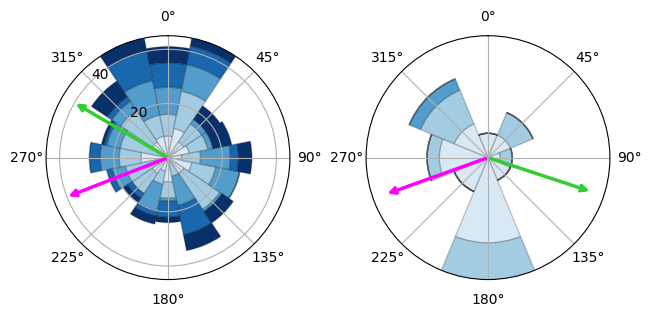

In [7]:
fig, axs = plt.subplots(1,2, subplot_kw={'projection':'polar'}, constrained_layout=True)
for ax, o in zip(axs, obs.itertuples(index=False)):
    d = groups[o.name]
    valid_dir = d.loc[d.TiltDis.gt(0) & np.isfinite(d.TiltDir)]
    ax = tilt.plot_windrose(ax, valid_dir, step=20, rlim=45 if o.name=='Murphy' else 10)
    
    th = np.deg2rad(o.bearing_deg)
    th = np.arctan2(np.mean(np.sin(th)), np.mean(np.cos(th)))
    ax.annotate('', xy=(th,.9*ax.get_ylim()[1]), xytext=(th,0),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='magenta'))

    th = np.deg2rad(pv_obs[pv_obs.name==o.name].iloc[0].PV_grad_theta)
    th = np.arctan2(np.mean(np.sin(th)), np.mean(np.cos(th)))
    ax.annotate('', xy=(th,.9*ax.get_ylim()[1]), xytext=(th,0),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='limegreen'))

## Optional export and interpretation

Read the location/count/depth checks before interpreting the histograms. A sparse or empty Ro-matched sample is a result, not a reason to silently widen the selection. The paper's peak readings, centre motion, very different radii, model resolution and fitting methods limit the comparison. Neither two matching observations nor the PV context establishes a causal tilt mechanism. Inspect whole-eddy weighting as a separate sensitivity before making population-inference claims.


In [8]:
if SAVE_RESULTS:
    import json
    from datetime import datetime, timezone
    run = OUTPUT / datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
    run.mkdir(parents=True, exist_ok=False)
    obs.to_csv(run / 'observations.csv', index=False)
    audit.to_csv(run / 'selection_audit.csv', index=False)
    comparison.to_csv(run / 'comparison.csv', index=False)
    metrics.to_csv(run / 'candidate_profile_metrics.csv', index=False)
    for name, d in groups.items():
        d.to_csv(run / f'{name.lower()}_matched_days.csv', index=False)
    pv_obs.to_csv(run / 'observed_pv_proxies.csv', index=False)
    pv_summary.to_csv(run / 'pv_comparison.csv', index=False)
    comparison_figure.savefig(run / 'tilt_comparison.png', dpi=180, bbox_inches='tight')
    inputs = {k: dict(path=str(v), size=Path(v).stat().st_size, mtime_ns=Path(v).stat().st_mtime_ns)
              for k, v in vars(PATHS).items()}
    settings = dict(radius_factor=RADIUS_FACTOR, ro_fraction=RO_FRACTION, target_depth_m=TARGET_DEPTH_M,
                    depth_tolerance_m=DEPTH_TOLERANCE_M, fit_min_depth_m=FIT_MIN_DEPTH_M,
                    rotation_rad=grid.angle, include_pv=INCLUDE_PV, weighting='eddy-day', inputs=inputs)
    (run / 'settings.json').write_text(json.dumps(settings, indent=2))
    print(run)


## Original working notes (preserved for provenance; superseded above)

Two cyclonic eddies in the EAC
\
Murphy
r=80km, lat=-28.8, lon=154
\
TDx=-20 km, TDy=-10 km, TD=23 km, TD/r $\approx$ 0.3
\
Ro=0.35, $\omega=-2.46e-5$
\
\
Freddy
r=17.5 km, lat=-32.5, lon=153.2
\
TDx=-10 km, TDy=-5 km, TD=12 km, TD/r $\approx$ 0.7
\
Ro=0.6, $\omega=-4.70e-5$